In [1]:
import os
import subprocess
import pandas as pd
import re
import pysam
import numpy as np
import matplotlib.pyplot as plt

In [2]:
vcf_files_dir = ("./STEPHENSI")
steph_vcf_file = f"{vcf_files_dir}/stephensi-untrimmed.vcf.gz"

output_file1 = f"{vcf_files_dir}/stephensi.untrimmed.nomadic_filtered_variants.vcf.gz"


In [3]:
#filter the vcf file to have only snps with above 2 alleles
%system bcftools view -m2 {steph_vcf_file} -Oz -o {output_file1}
%system bcftools index {output_file1}


[]

In [4]:
#read the anopheles stephbiae vcf file and create a csv file
vcf_file=pysam.VariantFile(output_file1)

def extract_amino_acid_change(annotation):
    match = re.search(r'\b(\d+[A-Z]>\d+[A-Z])\b', annotation)
    if match:
        return match.group(1)
    return None

def extract_gene_name(annotation):
    match = re.search(r'\|([A-Za-z0-9]+)\|', annotation)
    if match:
        return match.group(1)
    return None

def extract_gene_ids(annotation):
    # Search for the gene name pattern within the annotation
    match = re.search(r'\|([A-Za-z0-9_]+)\|', annotation)
    # If a match is found, return the gene name
    if match:
        return match.group(1)
    # Return None if no match is found
    return None
vcf_data = []


for record in vcf_file.fetch():
    vcf_data.append({
        "CHROM": record.chrom,
        "POS": record.pos,
        "ID": record.id,
        "REF": record.ref,
        "ALT": ','.join([str(alt) for alt in record.alts]), 
        "QUAL": record.qual,
        "FILTER": ','.join(record.filter.keys()),
        "ANN": record.info.get('BCSQ', None)
    })

steph_vcf_df = pd.DataFrame(vcf_data)


In [21]:
print(steph_vcf_df)

        CHROM       POS    ID REF ALT        QUAL FILTER  \
0    CM023248  60913392  None   T   C  170.001999   PASS   
1    CM023248  60913401  None   A   C  238.098007   PASS   
2    CM023248  60913404  None   G   A  238.097000   PASS   
3    CM023248  60913407  None   A   G  238.098999   PASS   
4    CM023248  60913416  None   A   G  238.097000   PASS   
..        ...       ...   ...  ..  ..         ...    ...   
658  CM023249  70581036  None   T   C  238.085007   PASS   
659  CM023249  70581037  None   G   A  238.093002   PASS   
660  CM023249  70581040  None   A   T  238.052002   PASS   
661  CM023249  70581042  None   G   C  238.063995   PASS   
662  CM023249  70581043  None   C   A  238.074005   PASS   

                                                   ANN  
0    (splice_region|ASTEI20_043445|ASTEI20_043445.R...  
1    (synonymous|ASTEI20_043445|ASTEI20_043445.R608...  
2    (synonymous|ASTEI20_043445|ASTEI20_043445.R608...  
3    (synonymous|ASTEI20_043445|ASTEI20_043445.R608

In [22]:
#save the dataframe and edit the file(remove all @ and (' and ',) on the ANN column MANUALLY IN AN EXCEL SHEET)
#Additionaly search @ and remove the @ and position i.e @2463572 and any other comma etc 
#example @42810262,’synonymous|ASTEI20_036354|ASTEI20_036354.R45604|protein_coding|-|1473S|42810263C>A remove @42810262,’ to remain with synonymous|ASTEI20_036354|ASTEI20_036354.R45604|protein_co
#@ represents double mutation at a particular aminoacid position i.e L995S and L995F
steph_vcf_df.to_csv("./STEPHENSI/steph_vcf_raw.csv")
steph_vcf_df.ANN

0      (splice_region|ASTEI20_043445|ASTEI20_043445.R...
1      (synonymous|ASTEI20_043445|ASTEI20_043445.R608...
2      (synonymous|ASTEI20_043445|ASTEI20_043445.R608...
3      (synonymous|ASTEI20_043445|ASTEI20_043445.R608...
4      (synonymous|ASTEI20_043445|ASTEI20_043445.R608...
                             ...                        
658                                         (@70581037,)
659    (missense|ASTEI20_040345|ASTEI20_040345.R53937...
660    (missense|ASTEI20_040345|ASTEI20_040345.R53937...
661                                         (@70581043,)
662    (missense|ASTEI20_040345|ASTEI20_040345.R53937...
Name: ANN, Length: 663, dtype: object

In [5]:
#reload the file and filter
steph_vcf_df = pd.read_csv("./STEPHENSI/steph_vcf_raw.csv")
steph_vcf_df

,Unnamed: 0,CHROM,POS,ID,REF,ALT,QUAL,FILTER,ANN
0,0,CM023248,60913392,NaN,T,C,170.001999,PASS,splice_region|ASTEI20_043445|ASTEI20_043445.R6...
1,1,CM023248,60913401,NaN,A,C,238.098007,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...
2,2,CM023248,60913404,NaN,G,A,238.097000,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...
3,3,CM023248,60913407,NaN,A,G,238.098999,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...
4,4,CM023248,60913416,NaN,A,G,238.097000,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...
...,...,...,...,...,...,...,...,...,...
658,658,CM023249,70581036,NaN,T,C,238.085007,PASS,@70581037
659,659,CM023249,70581037,NaN,G,A,238.093002,PASS,missense|ASTEI20_040345|ASTEI20_040345.R53937|...
660,660,CM023249,70581040,NaN,A,T,238.052002,PASS,missense|ASTEI20_040345|ASTEI20_040345.R53937|...
661,661,CM023249,70581042,NaN,G,C,238.063995,PASS,@70581043


In [6]:
# create a dataframe with annotation (geneid,protein change/mutation,location in chromosome/position)- this later helps with plotting
steph_vcf_df['gene_name'] = steph_vcf_df['ANN'].apply(lambda x: extract_gene_ids(str(x)))
steph_vcf_df['Protein_Change'] = steph_vcf_df['ANN'].apply(lambda x: extract_amino_acid_change(str(x)))
steph_vcf_df["LOCATION"]= (steph_vcf_df["CHROM"].astype(str) + ":" + steph_vcf_df["POS"].astype(str) + "-" + steph_vcf_df["gene_name"].astype(str)+ "-" + steph_vcf_df["Protein_Change"].astype(str))
steph_vcf_df

,Unnamed: 0,CHROM,POS,ID,REF,ALT,QUAL,FILTER,ANN,gene_name,Protein_Change,LOCATION
0,0,CM023248,60913392,NaN,T,C,170.001999,PASS,splice_region|ASTEI20_043445|ASTEI20_043445.R6...,ASTEI20_043445,None,CM023248:60913392-ASTEI20_043445-None
1,1,CM023248,60913401,NaN,A,C,238.098007,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...,ASTEI20_043445,None,CM023248:60913401-ASTEI20_043445-None
2,2,CM023248,60913404,NaN,G,A,238.097000,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...,ASTEI20_043445,None,CM023248:60913404-ASTEI20_043445-None
3,3,CM023248,60913407,NaN,A,G,238.098999,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...,ASTEI20_043445,None,CM023248:60913407-ASTEI20_043445-None
4,4,CM023248,60913416,NaN,A,G,238.097000,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...,ASTEI20_043445,None,CM023248:60913416-ASTEI20_043445-None
...,...,...,...,...,...,...,...,...,...,...,...,...
658,658,CM023249,70581036,NaN,T,C,238.085007,PASS,@70581037,None,None,CM023249:70581036-None-None
659,659,CM023249,70581037,NaN,G,A,238.093002,PASS,missense|ASTEI20_040345|ASTEI20_040345.R53937|...,ASTEI20_040345,12A>12V,CM023249:70581037-ASTEI20_040345-12A>12V
660,660,CM023249,70581040,NaN,A,T,238.052002,PASS,missense|ASTEI20_040345|ASTEI20_040345.R53937|...,ASTEI20_040345,11I>11N,CM023249:70581040-ASTEI20_040345-11I>11N
661,661,CM023249,70581042,NaN,G,C,238.063995,PASS,@70581043,None,None,CM023249:70581042-None-None


In [7]:
import sgkit as sg
from sgkit.io.vcf import vcf_to_zarr

##load the vcf file
vcf_to_zarr({output_file1},"output.zarr")
ds = sg.load_dataset("output.zarr")
print(ds)


/tmp/ipykernel_8379/1899366466.py:5: DeprecationWarning: Functions for reading VCF are deprecated, please use the bio2zarr package.
  vcf_to_zarr({output_file1},"output.zarr")


<xarray.Dataset> Size: 280kB
Dimensions:               (variants: 663, samples: 63, ploidy: 2, contigs: 495,
                           filters: 4, alleles: 4)
Dimensions without coordinates: variants, samples, ploidy, contigs, filters,
                                alleles
Data variables: (12/14)
    call_genotype         (variants, samples, ploidy) int8 84kB dask.array<chunksize=(663, 63, 2), meta=np.ndarray>
    call_genotype_mask    (variants, samples, ploidy) bool 84kB dask.array<chunksize=(663, 63, 2), meta=np.ndarray>
    call_genotype_phased  (variants, samples) bool 42kB dask.array<chunksize=(663, 63), meta=np.ndarray>
    contig_id             (contigs) <U15 30kB dask.array<chunksize=(495,), meta=np.ndarray>
    contig_length         (contigs) int64 4kB dask.array<chunksize=(495,), meta=np.ndarray>
    filter_id             (filters) object 32B dask.array<chunksize=(4,), meta=np.ndarray>
    ...                    ...
    variant_contig        (variants) int16 1kB dask.arra

In [8]:
df = ~ds.call_genotype_mask.to_dataframe()
call_rates = df.groupby('variants').mean()
call_rates

,call_genotype_mask
variants,
0,0.079365
1,1.000000
2,1.000000
3,1.000000
4,1.000000
...,...
658,1.000000
659,1.000000
660,1.000000


<Axes: title={'center': 'Anopheles stephensi\nCall Rate Distribution'}, ylabel='Frequency'>

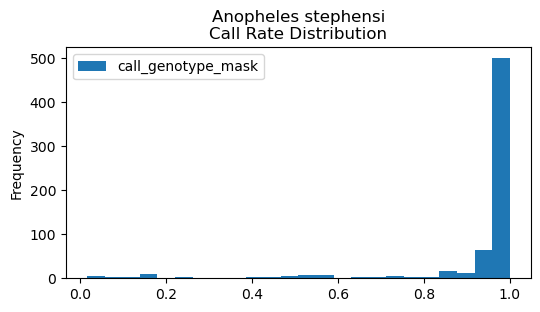

In [9]:
call_rates.plot(kind='hist', bins=24, title='Anopheles stephensi\nCall Rate Distribution', figsize=(6, 3))

In [10]:
steph_allele_count=sg.count_variant_alleles(ds)["variant_allele_count"].values
steph_allele_count

array([[  9,   1,   0,   0],
       [  0, 126,   0,   0],
       [  0, 126,   0,   0],
       ...,
       [  0, 126,   0,   0],
       [  0, 126,   0,   0],
       [  0, 126,   0,   0]], dtype=uint64)

In [11]:
steph_alleles=sg.count_variant_alleles(ds)["variant_allele_count"]
steph_alleles

<xarray.DataArray 'variant_allele_count' (variants: 663, alleles: 4)> Size: 21kB
dask.array<sum-aggregate, shape=(663, 4), dtype=uint64, chunksize=(663, 4), chunktype=numpy.ndarray>
Dimensions without coordinates: variants, alleles
Attributes:
    comment:  Variant allele counts. With shape (variants, alleles) and value...

In [12]:
allele_count= pd.DataFrame(steph_allele_count)

#change the column names
allele_count.columns=["ref","alt1","alt2","alt3"]
#create a new column with the total count
allele_count["total"]= allele_count.sum(axis=1)

#calculate the frequency for each allele count value
al_frequency_count= allele_count.div(allele_count["total"],axis=0)

#set the position as index 
al_frequency_count.set_index(steph_vcf_df["LOCATION"], inplace=True)

#round off the calculated values to 1d ecimal place
al_frequency_count=al_frequency_count.round(2)

al_frequency_count


,ref,alt1,alt2,alt3,total
LOCATION,,,,,
CM023248:60913392-ASTEI20_043445-None,0.9,0.1,0.0,0.0,1.0
CM023248:60913401-ASTEI20_043445-None,0.0,1.0,0.0,0.0,1.0
CM023248:60913404-ASTEI20_043445-None,0.0,1.0,0.0,0.0,1.0
CM023248:60913407-ASTEI20_043445-None,0.0,1.0,0.0,0.0,1.0
CM023248:60913416-ASTEI20_043445-None,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
CM023249:70581036-None-None,0.0,1.0,0.0,0.0,1.0
CM023249:70581037-ASTEI20_040345-12A>12V,0.0,1.0,0.0,0.0,1.0
CM023249:70581040-ASTEI20_040345-11I>11N,0.0,1.0,0.0,0.0,1.0


In [13]:
#merge the original vcf dataframe to the allele frequency results
merged_df = pd.merge(steph_vcf_df, al_frequency_count, on=["LOCATION"])

#save the merged file
merged_df.to_csv("./STEPHENSI/as_allele_merged.csv")
merged_df

,Unnamed: 0,CHROM,POS,ID,REF,ALT,QUAL,FILTER,ANN,gene_name,Protein_Change,LOCATION,ref,alt1,alt2,alt3,total
0,0,CM023248,60913392,NaN,T,C,170.001999,PASS,splice_region|ASTEI20_043445|ASTEI20_043445.R6...,ASTEI20_043445,None,CM023248:60913392-ASTEI20_043445-None,0.9,0.1,0.0,0.0,1.0
1,1,CM023248,60913401,NaN,A,C,238.098007,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...,ASTEI20_043445,None,CM023248:60913401-ASTEI20_043445-None,0.0,1.0,0.0,0.0,1.0
2,2,CM023248,60913404,NaN,G,A,238.097000,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...,ASTEI20_043445,None,CM023248:60913404-ASTEI20_043445-None,0.0,1.0,0.0,0.0,1.0
3,3,CM023248,60913407,NaN,A,G,238.098999,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...,ASTEI20_043445,None,CM023248:60913407-ASTEI20_043445-None,0.0,1.0,0.0,0.0,1.0
4,4,CM023248,60913416,NaN,A,G,238.097000,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...,ASTEI20_043445,None,CM023248:60913416-ASTEI20_043445-None,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
658,658,CM023249,70581036,NaN,T,C,238.085007,PASS,@70581037,None,None,CM023249:70581036-None-None,0.0,1.0,0.0,0.0,1.0
659,659,CM023249,70581037,NaN,G,A,238.093002,PASS,missense|ASTEI20_040345|ASTEI20_040345.R53937|...,ASTEI20_040345,12A>12V,CM023249:70581037-ASTEI20_040345-12A>12V,0.0,1.0,0.0,0.0,1.0
660,660,CM023249,70581040,NaN,A,T,238.052002,PASS,missense|ASTEI20_040345|ASTEI20_040345.R53937|...,ASTEI20_040345,11I>11N,CM023249:70581040-ASTEI20_040345-11I>11N,0.0,1.0,0.0,0.0,1.0
661,661,CM023249,70581042,NaN,G,C,238.063995,PASS,@70581043,None,None,CM023249:70581042-None-None,0.0,1.0,0.0,0.0,1.0


In [14]:
#Filter the merged file for plotting.Filtering missense and synonymous mutations to plot the mutation frequencies
missense_df = merged_df[(merged_df['ANN'].str.contains('missense',case=False, na=False)) & (merged_df['alt1'] >= 0.01)] #so we ignore all zeros
plot_missense = missense_df[['ref','alt1']]

synonymous_df = merged_df[(merged_df['ANN'].str.contains('synonymous',case=False, na=False)) & (merged_df['alt1'] >= 0.01)] 
plot_synonymous = synonymous_df[['ref','alt1']]

print(plot_missense)
print(plot_synonymous)


      ref  alt1
9    0.99  0.01
35   0.99  0.01
68   0.00  1.00
72   0.00  1.00
125  0.00  1.00
152  0.98  0.02
153  0.94  0.06
224  0.99  0.01
284  0.00  1.00
332  0.00  1.00
371  0.98  0.02
372  0.95  0.05
536  0.00  1.00
539  0.00  1.00
542  0.00  1.00
546  0.01  0.99
547  0.99  0.01
549  0.00  1.00
551  0.00  1.00
585  0.04  0.96
589  0.98  0.02
604  0.00  1.00
629  0.01  0.99
632  0.00  1.00
634  0.00  1.00
637  0.00  1.00
639  0.90  0.10
643  0.44  0.56
656  0.00  1.00
657  0.00  1.00
659  0.00  1.00
660  0.00  1.00
662  0.00  1.00
      ref  alt1
1    0.00  1.00
2    0.00  1.00
3    0.00  1.00
4    0.00  1.00
5    0.00  1.00
..    ...   ...
650  0.00  1.00
651  0.00  1.00
652  0.99  0.01
653  0.00  1.00
654  0.00  1.00

[262 rows x 2 columns]


In [15]:
#set index to the mutations df to help in labeling
plot_missense.set_index(missense_df["LOCATION"], inplace=True)
plot_synonymous.set_index(synonymous_df["LOCATION"], inplace=True)

print(plot_missense)
print(plot_synonymous)

                                               ref  alt1
LOCATION                                                
CM023248:60913439-ASTEI20_043445-312A>312S    0.99  0.01
CM023248:60913612-ASTEI20_043445-254R>254L    0.99  0.01
CM023248:60913844-ASTEI20_043445-177N>177D    0.00  1.00
CM023248:60913866-ASTEI20_043445-169E>169D    0.00  1.00
CM023248:60914095-ASTEI20_043445-118P>118A    0.00  1.00
CM023249:8353006-ASTEI20_036292-312T>312M     0.98  0.02
CM023249:8353055-ASTEI20_036292-296A>296S     0.94  0.06
CM023249:42810151-ASTEI20_036354-1484T>1484M  0.99  0.01
CM023249:42810376-ASTEI20_036354-1436T>1436S  0.00  1.00
CM023249:42817424-ASTEI20_036354-1042V>1042L  0.00  1.00
CM023249:42817709-ASTEI20_036354-993L>993F    0.98  0.02
CM023249:42817710-ASTEI20_036354-993L>993S    0.95  0.05
CM023249:70580426-ASTEI20_040345-171A>171S    0.00  1.00
CM023249:70580450-ASTEI20_040345-163L>163V    0.00  1.00
CM023249:70580471-ASTEI20_040345-156R>156G    0.00  1.00
CM023249:70580510-ASTEI20_04034

In [41]:
intron=merged_df[
    (merged_df['ANN'].str.contains('synonymous', case=False, na=False)) 
]
intron.count()

Unnamed: 0        262
CHROM             262
POS               262
ID                  0
REF               262
ALT               262
QUAL              262
FILTER            262
ANN               262
gene_name         262
Protein_Change      0
LOCATION          262
ref               262
alt1              262
alt2              262
alt3              262
total             262
dtype: int64

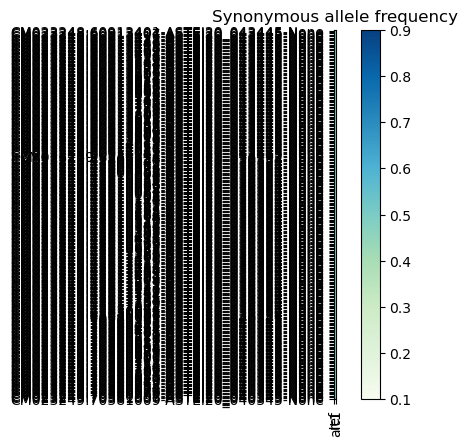

In [16]:
#heatmap plot for the allele counts(synonymous)
plt.imshow(plot_synonymous, cmap='GnBu',vmin=0.1, vmax=0.9)
plt.yticks(ticks=range(len(plot_synonymous.index)), labels=plot_synonymous.index)
plt.xticks(ticks=range(len(plot_synonymous.columns)), labels=plot_synonymous.columns,rotation=90)
plt.title('Synonymous allele frequency')
plt.colorbar()
plt.show()


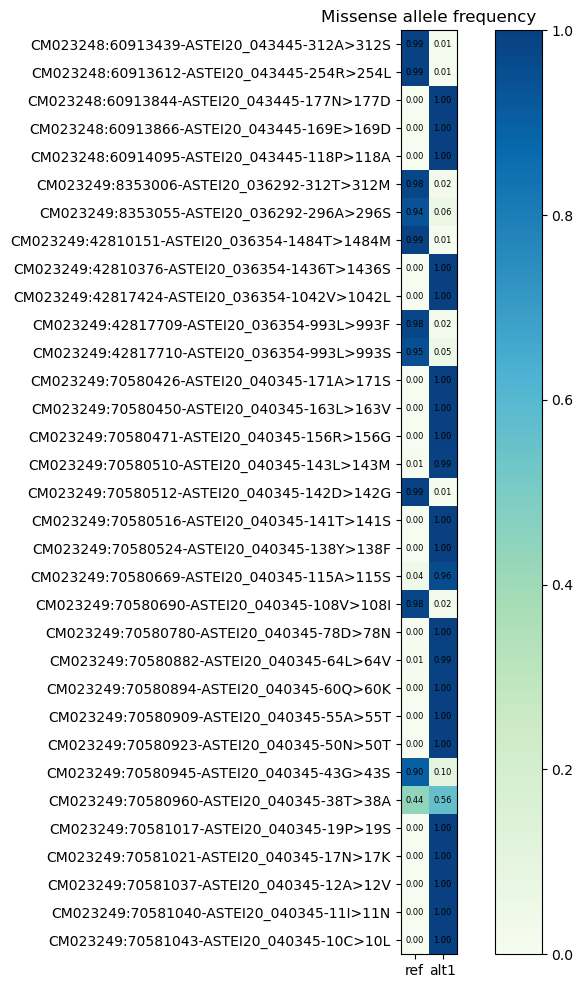

In [17]:
#heatmap plot for the allele counts(missense)
plt.figure(figsize=(10, 12))
plt.imshow(plot_missense, cmap='GnBu',vmin=0, vmax=1)
plt.yticks(ticks=range(len(plot_missense.index)), labels=plot_missense.index)
plt.xticks(ticks=range(len(plot_missense.columns)), labels=plot_missense.columns)
plt.title('Missense allele frequency')
plt.colorbar()
for i in range(len(plot_missense.index)):
    for j in range(len(plot_missense.columns)):
        value = plot_missense.iloc[i, j]
        plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black', fontsize=6)
plt.show()
plt.show()


In [18]:
#calculate the genotype count
genotype_count=sg.count_variant_genotypes(ds)["variant_genotype_count"].values

#change it to a dataframe and calculate the total for each variant
genotype_count= pd.DataFrame(genotype_count)
genotype_count["total"]= genotype_count.sum(axis=1)

#calculate the genptype frequencies
genotype_frequency_count= genotype_count.div(genotype_count["total"],axis=0)

#set the position as index 
genotype_frequency_count.set_index(steph_vcf_df["LOCATION"], inplace=True)
genotype_frequency_count

,0,1,2,3,4,5,6,7,8,9,total
LOCATION,,,,,,,,,,,
CM023248:60913392-ASTEI20_043445-None,0.8,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM023248:60913401-ASTEI20_043445-None,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM023248:60913404-ASTEI20_043445-None,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM023248:60913407-ASTEI20_043445-None,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM023248:60913416-ASTEI20_043445-None,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
CM023249:70581036-None-None,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM023249:70581037-ASTEI20_040345-12A>12V,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM023249:70581040-ASTEI20_040345-11I>11N,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [19]:
#this help us know the corresponding column names so that i can use them to re-lable using the 
sg.count_variant_genotypes(ds)["variant_genotype_count"]

<xarray.DataArray 'variant_genotype_count' (variants: 663, genotypes: 10)> Size: 53kB
dask.array<_count_sorted_genotypes, shape=(663, 10), dtype=uint64, chunksize=(663, 10), chunktype=numpy.ndarray>
Coordinates:
  * genotypes  (genotypes) <U3 120B '0/0' '0/1' '1/1' ... '1/3' '2/3' '3/3'
Dimensions without coordinates: variants
Attributes:
    comment:  The number of observations for each possible genotype at each v...

In [20]:
#change the column name to this
genotype_frequency_count.columns=['GT:0/0', 'GT:0/1', 'GT:1/1', 'GT:0/2', 'GT:1/2', 'GT:2/2', 'GT:0/3','GT:1/3','GT:2/3', 'GT:3/3','total']

In [21]:
#round off the calculated values to 1d ecimal place
genotype_frequency_count=genotype_frequency_count.round(2)
genotype_frequency_count

,GT:0/0,GT:0/1,GT:1/1,GT:0/2,GT:1/2,GT:2/2,GT:0/3,GT:1/3,GT:2/3,GT:3/3,total
LOCATION,,,,,,,,,,,
CM023248:60913392-ASTEI20_043445-None,0.8,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM023248:60913401-ASTEI20_043445-None,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM023248:60913404-ASTEI20_043445-None,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM023248:60913407-ASTEI20_043445-None,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM023248:60913416-ASTEI20_043445-None,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
CM023249:70581036-None-None,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM023249:70581037-ASTEI20_040345-12A>12V,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM023249:70581040-ASTEI20_040345-11I>11N,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [22]:
#merge the original vcf dataframe to the allele frequency results
genotype_merged_df = pd.merge(steph_vcf_df, genotype_frequency_count, on=["LOCATION"])

#save the merged file
genotype_merged_df.to_csv("/home/cynthia/variants/as_genotype_merged.csv")
genotype_merged_df

,Unnamed: 0,CHROM,POS,ID,REF,ALT,QUAL,FILTER,ANN,gene_name,...,GT:0/1,GT:1/1,GT:0/2,GT:1/2,GT:2/2,GT:0/3,GT:1/3,GT:2/3,GT:3/3,total
0,0,CM023248,60913392,NaN,T,C,170.001999,PASS,splice_region|ASTEI20_043445|ASTEI20_043445.R6...,ASTEI20_043445,...,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,CM023248,60913401,NaN,A,C,238.098007,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...,ASTEI20_043445,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2,CM023248,60913404,NaN,G,A,238.097000,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...,ASTEI20_043445,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,CM023248,60913407,NaN,A,G,238.098999,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...,ASTEI20_043445,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,4,CM023248,60913416,NaN,A,G,238.097000,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...,ASTEI20_043445,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
658,658,CM023249,70581036,NaN,T,C,238.085007,PASS,@70581037,None,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
659,659,CM023249,70581037,NaN,G,A,238.093002,PASS,missense|ASTEI20_040345|ASTEI20_040345.R53937|...,ASTEI20_040345,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
660,660,CM023249,70581040,NaN,A,T,238.052002,PASS,missense|ASTEI20_040345|ASTEI20_040345.R53937|...,ASTEI20_040345,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
661,661,CM023249,70581042,NaN,G,C,238.063995,PASS,@70581043,None,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [23]:
##Filter the merged file for plotting.Filtering missense and synonymous mutations to plot the mutation frequencies
genotype_missense_df = genotype_merged_df[(genotype_merged_df['ANN'].str.contains('missense',case=False, na=False)) & (genotype_merged_df['GT:0/1'] >= 0.01)] #so we ignore all zeros
plotgt_missense = genotype_missense_df[['GT:0/0','GT:0/1','GT:1/1']]

genotype_synonymous_df = genotype_merged_df[(genotype_merged_df['ANN'].str.contains('synonymous',case=False, na=False)) & (genotype_merged_df['GT:0/1'] >= 0.01)] 
plotgt_synonymous = genotype_synonymous_df[['GT:0/0','GT:0/1','GT:1/1']]

print(plotgt_missense)
print(plotgt_synonymous)

     GT:0/0  GT:0/1  GT:1/1
9      0.98    0.02    0.00
35     0.98    0.02    0.00
153    0.92    0.05    0.03
224    0.98    0.02    0.00
371    0.97    0.02    0.02
372    0.92    0.07    0.02
546    0.00    0.02    0.98
547    0.98    0.02    0.00
585    0.02    0.05    0.94
589    0.95    0.05    0.00
629    0.00    0.02    0.98
639    0.80    0.20    0.00
643    0.15    0.58    0.27
     GT:0/0  GT:0/1  GT:1/1
7      0.94    0.05    0.02
13     0.98    0.02    0.00
36     0.98    0.02    0.00
37     0.38    0.38    0.24
42     0.46    0.30    0.24
50     0.98    0.02    0.00
54     0.98    0.02    0.00
62     0.95    0.02    0.03
81     0.60    0.32    0.08
82     0.05    0.13    0.83
116    0.11    0.29    0.60
119    0.98    0.02    0.00
120    0.98    0.02    0.00
121    0.68    0.17    0.14
204    0.98    0.02    0.00
274    0.05    0.44    0.52
341    0.00    0.02    0.98
389    0.00    1.00    0.00
531    0.47    0.44    0.10
534    0.00    0.32    0.68
540    0.97    0.03 

In [24]:
#set index to the mutations df to help in labelling
plotgt_missense.set_index(genotype_missense_df["LOCATION"], inplace=True)
plotgt_synonymous.set_index(genotype_synonymous_df["LOCATION"], inplace=True)

print(plotgt_missense)
plotgt_synonymous

                                              GT:0/0  GT:0/1  GT:1/1
LOCATION                                                            
CM023248:60913439-ASTEI20_043445-312A>312S      0.98    0.02    0.00
CM023248:60913612-ASTEI20_043445-254R>254L      0.98    0.02    0.00
CM023249:8353055-ASTEI20_036292-296A>296S       0.92    0.05    0.03
CM023249:42810151-ASTEI20_036354-1484T>1484M    0.98    0.02    0.00
CM023249:42817709-ASTEI20_036354-993L>993F      0.97    0.02    0.02
CM023249:42817710-ASTEI20_036354-993L>993S      0.92    0.07    0.02
CM023249:70580510-ASTEI20_040345-143L>143M      0.00    0.02    0.98
CM023249:70580512-ASTEI20_040345-142D>142G      0.98    0.02    0.00
CM023249:70580669-ASTEI20_040345-115A>115S      0.02    0.05    0.94
CM023249:70580690-ASTEI20_040345-108V>108I      0.95    0.05    0.00
CM023249:70580882-ASTEI20_040345-64L>64V        0.00    0.02    0.98
CM023249:70580945-ASTEI20_040345-43G>43S        0.80    0.20    0.00
CM023249:70580960-ASTEI20_040345-3

,GT:0/0,GT:0/1,GT:1/1
LOCATION,,,
CM023248:60913431-ASTEI20_043445-None,0.94,0.05,0.02
CM023248:60913458-ASTEI20_043445-None,0.98,0.02,0.00
CM023248:60913614-ASTEI20_043445-None,0.98,0.02,0.00
CM023248:60913617-ASTEI20_043445-None,0.38,0.38,0.24
CM023248:60913656-ASTEI20_043445-None,0.46,0.30,0.24
CM023248:60913734-ASTEI20_043445-None,0.98,0.02,0.00
CM023248:60913761-ASTEI20_043445-None,0.98,0.02,0.00
CM023248:60913799-ASTEI20_043445-None,0.95,0.02,0.03
CM023248:60913913-ASTEI20_043445-None,0.60,0.32,0.08


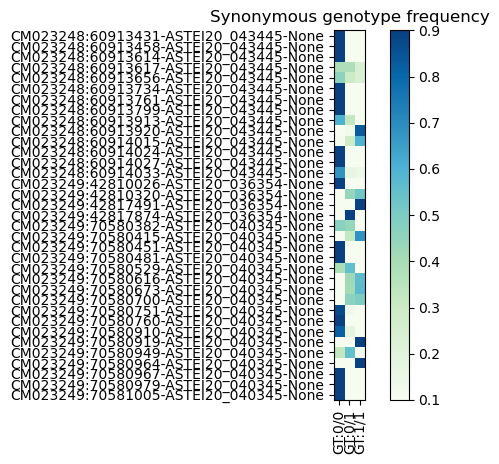

In [25]:
#heatmap plot for the allele counts(synonymous)
plt.imshow(plotgt_synonymous, cmap='GnBu',vmin=0.1, vmax=0.9)
plt.yticks(ticks=range(len(plotgt_synonymous.index)), labels=plotgt_synonymous.index,)
plt.xticks(ticks=range(len(plotgt_synonymous.columns)), labels=plotgt_synonymous.columns, rotation=90)
plt.title('Synonymous genotype frequency')
plt.colorbar()
plt.show()


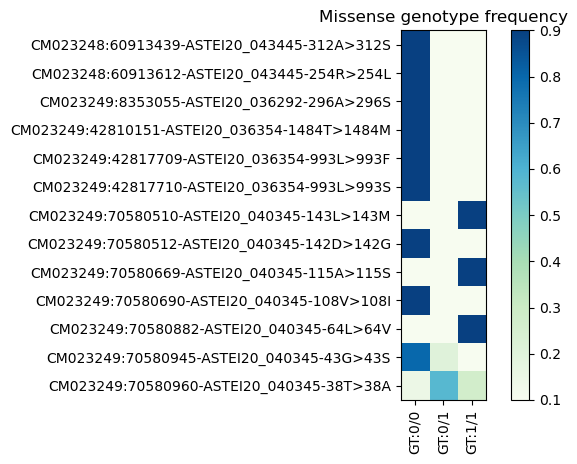

In [26]:
#heatmap plot for the allele counts(missense)
plt.imshow(plotgt_missense, cmap='GnBu',vmin=0.1, vmax=0.9)
plt.yticks(ticks=range(len(plotgt_missense.index)), labels=plotgt_missense.index)
plt.xticks(ticks=range(len(plotgt_missense.columns)), labels=plotgt_missense.columns, rotation=90)
plt.title('Missense genotype frequency')
plt.colorbar()
plt.show()


In [27]:
#merge the final dataframe ()
as_al_gt_merged_df = pd.merge(genotype_merged_df, al_frequency_count, on=["LOCATION"])
as_al_gt_merged_df.to_csv("./STEPHENSI/as_al_gt_merged.csv")
as_al_gt_merged_df

,Unnamed: 0,CHROM,POS,ID,REF,ALT,QUAL,FILTER,ANN,gene_name,...,GT:0/3,GT:1/3,GT:2/3,GT:3/3,total_x,ref,alt1,alt2,alt3,total_y
0,0,CM023248,60913392,NaN,T,C,170.001999,PASS,splice_region|ASTEI20_043445|ASTEI20_043445.R6...,ASTEI20_043445,...,0.0,0.0,0.0,0.0,1.0,0.9,0.1,0.0,0.0,1.0
1,1,CM023248,60913401,NaN,A,C,238.098007,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...,ASTEI20_043445,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,2,CM023248,60913404,NaN,G,A,238.097000,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...,ASTEI20_043445,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3,3,CM023248,60913407,NaN,A,G,238.098999,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...,ASTEI20_043445,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,4,CM023248,60913416,NaN,A,G,238.097000,PASS,synonymous|ASTEI20_043445|ASTEI20_043445.R6085...,ASTEI20_043445,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
658,658,CM023249,70581036,NaN,T,C,238.085007,PASS,@70581037,None,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
659,659,CM023249,70581037,NaN,G,A,238.093002,PASS,missense|ASTEI20_040345|ASTEI20_040345.R53937|...,ASTEI20_040345,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
660,660,CM023249,70581040,NaN,A,T,238.052002,PASS,missense|ASTEI20_040345|ASTEI20_040345.R53937|...,ASTEI20_040345,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
661,661,CM023249,70581042,NaN,G,C,238.063995,PASS,@70581043,None,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


In [28]:
# Filter for GSTE
gste_df = as_al_gt_merged_df[(as_al_gt_merged_df['ANN'].str.contains('ASTEI20_040345', case=False, na=False)) & (as_al_gt_merged_df['ANN'].str.contains('missense', case=False, na=False))] 
plot_gste = gste_df[['ref', 'alt1']]
plot_gste.columns = ['Reference', 'Alternate']
psteph_df = as_al_gt_merged_df[(as_al_gt_merged_df['ANN'].str.contains('ASTEI20_036354', case=False, na=False)) & (as_al_gt_merged_df['ANN'].str.contains('missense', case=False, na=False))] 
plot_psteph = psteph_df[['ref', 'alt1']]
plot_psteph.columns = ['Reference', 'Alternate']
ace_df = as_al_gt_merged_df[(as_al_gt_merged_df['ANN'].str.contains('ASTEI20_043445', case=False, na=False)) & (as_al_gt_merged_df['ANN'].str.contains('missense', case=False, na=False))] 
plot_ace = ace_df[['ref', 'alt1']]
plot_ace.columns = ['Reference', 'Alternate']
rdl_df = as_al_gt_merged_df[(as_al_gt_merged_df['ANN'].str.contains('ASTEI20_036292', case=False, na=False)) & (as_al_gt_merged_df['ANN'].str.contains('missense', case=False, na=False))] 
plot_rdl = rdl_df[['ref', 'alt1']]
plot_rdl.columns = ['Reference', 'Alternate']
plot_gste


,Reference,Alternate
536,0.00,1.00
539,0.00,1.00
542,0.00,1.00
546,0.01,0.99
547,0.99,0.01
549,0.00,1.00
551,0.00,1.00
585,0.04,0.96
589,0.98,0.02
604,0.00,1.00


In [29]:
#set index to the mutations df to help in labeling
plot_psteph.set_index(psteph_df["LOCATION"], inplace=True)
plot_gste.set_index(gste_df["LOCATION"], inplace=True)
plot_ace.set_index(ace_df["LOCATION"], inplace=True)
plot_rdl.set_index(rdl_df["LOCATION"], inplace=True)


print(plot_gste)
#print(plot_psteph)

                                            Reference  Alternate
LOCATION                                                        
CM023249:70580426-ASTEI20_040345-171A>171S       0.00       1.00
CM023249:70580450-ASTEI20_040345-163L>163V       0.00       1.00
CM023249:70580471-ASTEI20_040345-156R>156G       0.00       1.00
CM023249:70580510-ASTEI20_040345-143L>143M       0.01       0.99
CM023249:70580512-ASTEI20_040345-142D>142G       0.99       0.01
CM023249:70580516-ASTEI20_040345-141T>141S       0.00       1.00
CM023249:70580524-ASTEI20_040345-138Y>138F       0.00       1.00
CM023249:70580669-ASTEI20_040345-115A>115S       0.04       0.96
CM023249:70580690-ASTEI20_040345-108V>108I       0.98       0.02
CM023249:70580780-ASTEI20_040345-78D>78N         0.00       1.00
CM023249:70580882-ASTEI20_040345-64L>64V         0.01       0.99
CM023249:70580894-ASTEI20_040345-60Q>60K         0.00       1.00
CM023249:70580909-ASTEI20_040345-55A>55T         0.00       1.00
CM023249:70580923-ASTEI20

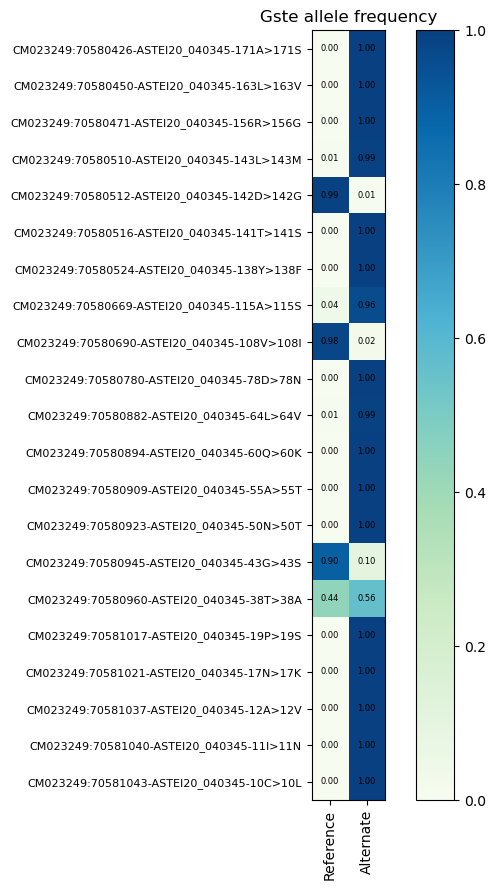

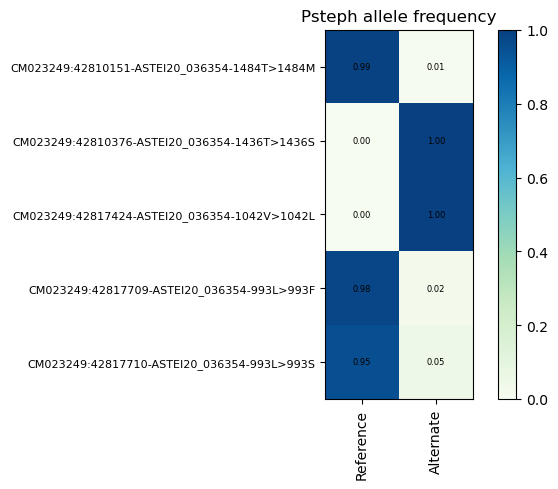

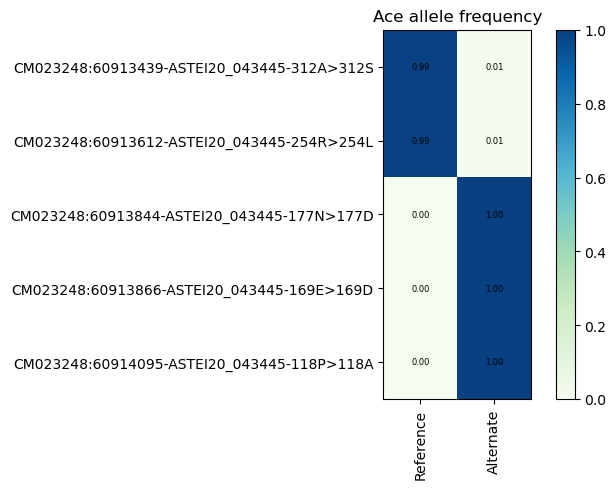

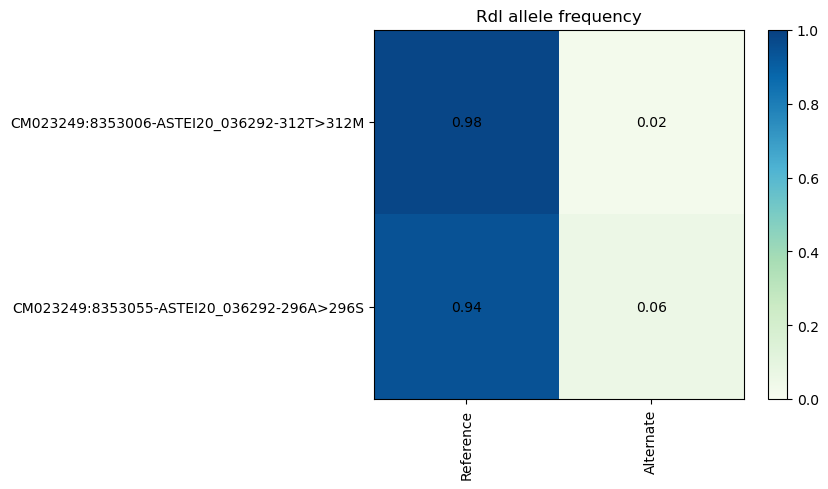

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
plt.imshow(plot_gste, cmap='GnBu',vmin=0, vmax=1)
plt.yticks(ticks=range(len(plot_gste.index)), labels=plot_gste.index , fontsize=8)
plt.xticks(ticks=range(len(plot_gste.columns)), labels=plot_gste.columns,rotation=90)
plt.title('Gste allele frequency')
plt.colorbar()
for i in range(len(plot_gste.index)):
    for j in range(len(plot_gste.columns)):
        value = plot_gste.iloc[i, j]
        plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black', fontsize=6)
plt.show()


plt.imshow(plot_psteph, cmap='GnBu',vmin=0.0, vmax=1)
plt.yticks(ticks=range(len(plot_psteph.index)), labels=plot_psteph.index,fontsize=8)
plt.xticks(ticks=range(len(plot_psteph.columns)), labels=plot_psteph.columns,rotation=90)
plt.title('Psteph allele frequency')
plt.colorbar()
for i in range(len(plot_psteph.index)):
    for j in range(len(plot_psteph.columns)):
        value = plot_psteph.iloc[i, j]
        plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black',fontsize=6)
plt.show()


#plt.figure(figsize=(8, 10)) 
plt.imshow(plot_ace, cmap='GnBu',vmin=0.0, vmax=1)
plt.yticks(ticks=range(len(plot_ace.index)), labels=plot_ace.index)
plt.xticks(ticks=range(len(plot_ace.columns)), labels=plot_ace.columns,rotation=90)
plt.title('Ace allele frequency')
plt.colorbar()
for i in range(len(plot_ace.index)):
    for j in range(len(plot_ace.columns)):
        value = plot_ace.iloc[i, j]
        plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black', fontsize=6)
plt.show()


plt.imshow(plot_rdl, cmap='GnBu',vmin=0.0, vmax=1)
plt.yticks(ticks=range(len(plot_rdl.index)), labels=plot_rdl.index)
plt.xticks(ticks=range(len(plot_rdl.columns)), labels=plot_rdl.columns,rotation=90)
plt.title('Rdl allele frequency')
plt.colorbar()
for i in range(len(plot_rdl.index)):
    for j in range(len(plot_rdl.columns)):
        value = plot_rdl.iloc[i, j]
        plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black')
plt.show()

In [31]:
# Filter for GSTE
gste_df = as_al_gt_merged_df[(as_al_gt_merged_df['ANN'].str.contains('ASTEI20_040345', case=False, na=False)) & (as_al_gt_merged_df['ANN'].str.contains('missense', case=False, na=False))] 
plot_gste = gste_df[['ref', 'alt1','GT:0/0', 'GT:0/1', 'GT:1/1']]
plot_gste.columns = ['Reference', 'Alternate','GT:0/0', 'GT:0/1', 'GT:1/1']
psteph_df = as_al_gt_merged_df[(as_al_gt_merged_df['ANN'].str.contains('ASTEI20_036354', case=False, na=False)) & (as_al_gt_merged_df['ANN'].str.contains('missense', case=False, na=False))] 
plot_psteph = psteph_df[['ref', 'alt1','GT:0/0', 'GT:0/1', 'GT:1/1']]
plot_psteph.columns = ['Reference', 'Alternate','GT:0/0', 'GT:0/1', 'GT:1/1']
ace_df = as_al_gt_merged_df[(as_al_gt_merged_df['ANN'].str.contains('ASTEI20_043445', case=False, na=False)) & (as_al_gt_merged_df['ANN'].str.contains('missense', case=False, na=False))] 
plot_ace = ace_df[['ref', 'alt1','GT:0/0', 'GT:0/1', 'GT:1/1']]
plot_ace.columns = ['Reference', 'Alternate','GT:0/0', 'GT:0/1', 'GT:1/1']
rdl_df = as_al_gt_merged_df[(as_al_gt_merged_df['ANN'].str.contains('ASTEI20_036292', case=False, na=False)) & (as_al_gt_merged_df['ANN'].str.contains('missense', case=False, na=False))] 
plot_rdl = rdl_df[['ref', 'alt1','GT:0/0', 'GT:0/1', 'GT:1/1']]
plot_rdl.columns = ['Reference', 'Alternate','GT:0/0', 'GT:0/1', 'GT:1/1']
plot_gste

,Reference,Alternate,GT:0/0,GT:0/1,GT:1/1
536,0.00,1.00,0.00,0.00,1.00
539,0.00,1.00,0.00,0.00,1.00
542,0.00,1.00,0.00,0.00,1.00
546,0.01,0.99,0.00,0.02,0.98
547,0.99,0.01,0.98,0.02,0.00
549,0.00,1.00,0.00,0.00,1.00
551,0.00,1.00,0.00,0.00,1.00
585,0.04,0.96,0.02,0.05,0.94
589,0.98,0.02,0.95,0.05,0.00
604,0.00,1.00,0.00,0.00,1.00


In [32]:
#plot for both allele and genotype frequecies
# Filter for GSTE
#set index to the mutations df to help in labeling
plot_psteph.set_index(psteph_df["LOCATION"], inplace=True)
plot_gste.set_index(gste_df["LOCATION"], inplace=True)
plot_ace.set_index(ace_df["LOCATION"], inplace=True)
plot_rdl.set_index(rdl_df["LOCATION"], inplace=True)
plot_ace

,Reference,Alternate,GT:0/0,GT:0/1,GT:1/1
LOCATION,,,,,
CM023248:60913439-ASTEI20_043445-312A>312S,0.99,0.01,0.98,0.02,0.0
CM023248:60913612-ASTEI20_043445-254R>254L,0.99,0.01,0.98,0.02,0.0
CM023248:60913844-ASTEI20_043445-177N>177D,0.00,1.00,0.00,0.00,1.0
CM023248:60913866-ASTEI20_043445-169E>169D,0.00,1.00,0.00,0.00,1.0
CM023248:60914095-ASTEI20_043445-118P>118A,0.00,1.00,0.00,0.00,1.0


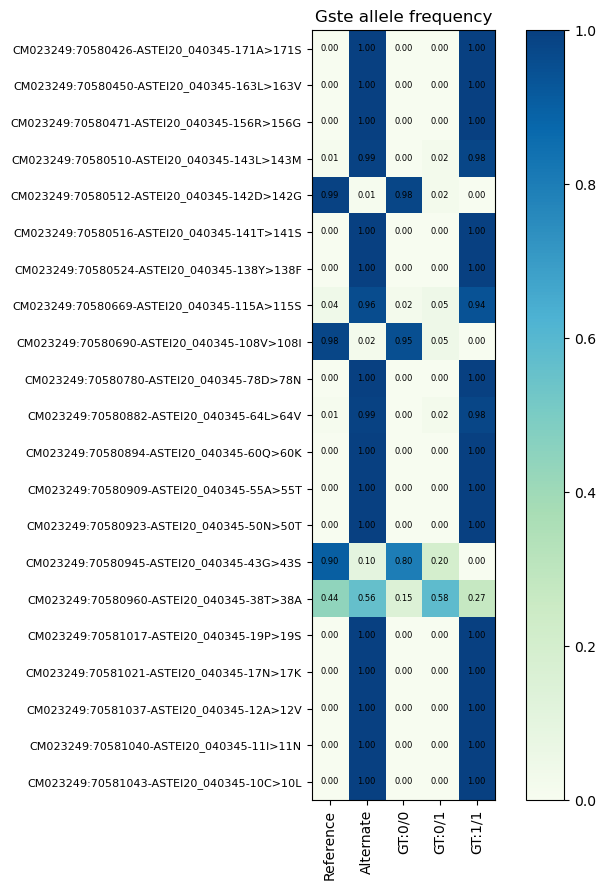

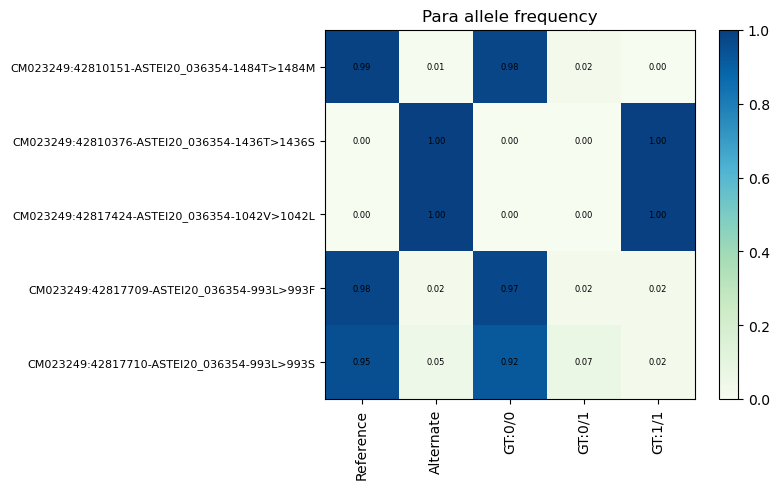

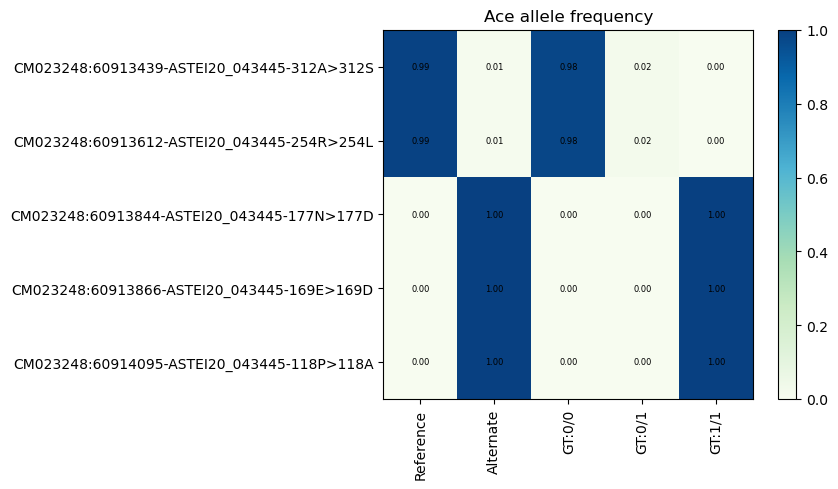

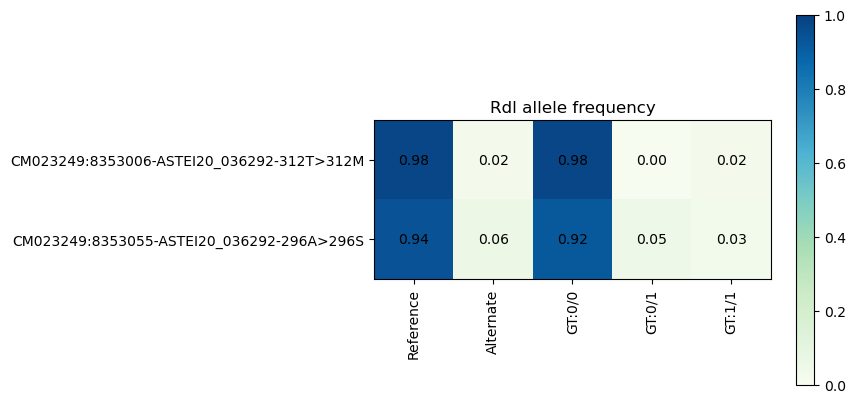

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
plt.imshow(plot_gste, cmap='GnBu',vmin=0, vmax=1)
plt.yticks(ticks=range(len(plot_gste.index)), labels=plot_gste.index , fontsize=8)
plt.xticks(ticks=range(len(plot_gste.columns)), labels=plot_gste.columns,rotation=90)
plt.title('Gste allele frequency')
plt.colorbar()
for i in range(len(plot_gste.index)):
    for j in range(len(plot_gste.columns)):
        value = plot_gste.iloc[i, j]
        plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black', fontsize=6)
plt.show()


plt.imshow(plot_psteph, cmap='GnBu',vmin=0.0, vmax=1)
plt.yticks(ticks=range(len(plot_psteph.index)), labels=plot_psteph.index,fontsize=8)
plt.xticks(ticks=range(len(plot_psteph.columns)), labels=plot_psteph.columns,rotation=90)
plt.title('Para allele frequency')
plt.colorbar()
for i in range(len(plot_psteph.index)):
    for j in range(len(plot_psteph.columns)):
        value = plot_psteph.iloc[i, j]
        plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black',fontsize=6)
plt.show()


#plt.figure(figsize=(8, 10)) 
plt.imshow(plot_ace, cmap='GnBu',vmin=0.0, vmax=1)
plt.yticks(ticks=range(len(plot_ace.index)), labels=plot_ace.index)
plt.xticks(ticks=range(len(plot_ace.columns)), labels=plot_ace.columns,rotation=90)
plt.title('Ace allele frequency')
plt.colorbar()
for i in range(len(plot_ace.index)):
    for j in range(len(plot_ace.columns)):
        value = plot_ace.iloc[i, j]
        plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black', fontsize=6)
plt.show()


plt.imshow(plot_rdl, cmap='GnBu',vmin=0.0, vmax=1)
plt.yticks(ticks=range(len(plot_rdl.index)), labels=plot_rdl.index)
plt.xticks(ticks=range(len(plot_rdl.columns)), labels=plot_rdl.columns,rotation=90)
plt.title('Rdl allele frequency')
plt.colorbar()
for i in range(len(plot_rdl.index)):
    for j in range(len(plot_rdl.columns)):
        value = plot_rdl.iloc[i, j]
        plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black')
plt.show()

In [1]:
merged_all_df=as_al_gt_merged_df[(as_al_gt_merged_df['ANN'].str.contains('missense',case=False, na=False)) & (as_al_gt_merged_df['ref'] >= 0.1)]
merged_all_df

#merged_all_df.to_csv("./STEPHENSI/stephensi_final.csv")

NameError: name 'as_al_gt_merged_df' is not defined

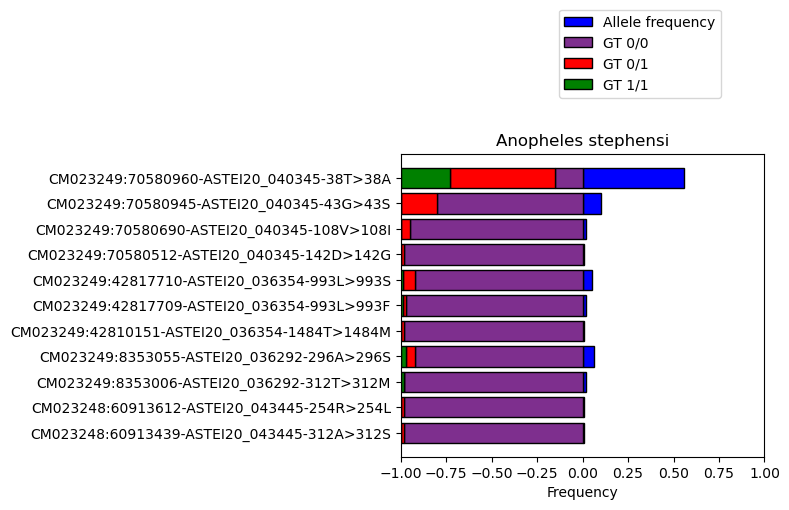

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# SNPS data
positions = np.array(merged_all_df["LOCATION"])
aa_change = np.array(merged_all_df["alt1"])

# Genotype data
snps_gt_00 = -np.array(merged_all_df["GT:0/0"])  # GT 0/0
snps_gt_01 = -np.array(merged_all_df["GT:0/1"])  # GT 0/1
snps_gt_11 = -np.array(merged_all_df["GT:1/1"])  # GT 1/1

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the allele frequency
ax.barh( positions, aa_change, color='blue', edgecolor='black', label='Allele frequency')

# Plot stacked genotype frequencies
bottom = np.zeros(len(positions))
ax.barh(positions, snps_gt_00, left=bottom, color="#7E2F8E", edgecolor='black', label='GT 0/0')
bottom += snps_gt_00
ax.barh(positions, snps_gt_01, left=bottom, color='red', edgecolor='black', label='GT 0/1')
bottom += snps_gt_01
ax.barh(positions, snps_gt_11, left=bottom, color='green', edgecolor='black', label='GT 1/1')


# Adding labels and title
ax.set_xlabel('Frequency')
#ax.set_xlim(-10, 10)
ax.set_title('Anopheles stephensi')
ax.legend(loc='upper right',bbox_to_anchor=(0.9, 1.5))
ax.set_xlim(-1, 1)
# Display the plot
plt.tight_layout()
plt.show()

In [35]:
#create a new column with gene symbol
#merged_all_df
#dictionary
gene_mapping = {
    'ASTEI20_043445': 'Ace2',
    'ASTEI20_036354': 'Vgsc',
    'ASTEI20_036292': 'Gaba',
    'ASTEI20_040345': 'Gste2',
}

# Create new column with mapped values
merged_all_df['Gene_symbol'] = merged_all_df['gene_name'].map(gene_mapping).fillna(merged_all_df['gene_name'])
merged_all_df.Gene_symbol

#create new column with final plot label
merged_all_df["Label"]= (merged_all_df["Gene_symbol"].astype(str) + "(" + merged_all_df["Protein_Change"].astype(str) + ")")
merged_all_df.Label

/tmp/ipykernel_8379/4293915315.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_all_df['Gene_symbol'] = merged_all_df['gene_name'].map(gene_mapping).fillna(merged_all_df['gene_name'])
/tmp/ipykernel_8379/4293915315.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_all_df["Label"]= (merged_all_df["Gene_symbol"].astype(str) + "(" + merged_all_df["Protein_Change"].astype(str) + ")")


9        Ace2(312A>312S)
35       Ace2(254R>254L)
152      Gaba(312T>312M)
153      Gaba(296A>296S)
224    Vgsc(1484T>1484M)
371      Vgsc(993L>993F)
372      Vgsc(993L>993S)
547     Gste2(142D>142G)
589     Gste2(108V>108I)
639       Gste2(43G>43S)
643       Gste2(38T>38A)
Name: Label, dtype: object

In [36]:
#change the aminoacid position to known gambiae position RD
#for kdr east/west VGSC region
merged_all_df.at[372, 'Label'] = 'Vgsc(995L>995S)'
merged_all_df.at[372, 'Label'] 

merged_all_df.at[371, 'Label'] = 'Vgsc(995L>995F)'
merged_all_df.at[371, 'Label'] 

merged_all_df.at[224, 'Label'] = 'Vgsc(1515T>1515M)'
merged_all_df.at[224, 'Label'] 

merged_all_df.at[643, 'Label'] = 'Gste2(21T>21A)'
merged_all_df.at[643, 'Label'] 

merged_all_df.at[639, 'Label'] = 'Gste2(26G>26S)'
merged_all_df.at[639, 'Label'] 

merged_all_df.at[589, 'Label'] = 'Gste2(91V>91I)'
merged_all_df.at[589, 'Label'] 

merged_all_df.at[547, 'Label'] = 'Gste2(125D>125G)'
merged_all_df.at[547, 'Label'] 

merged_all_df.to_csv("./STEPHENSI/steph_merged.csv")

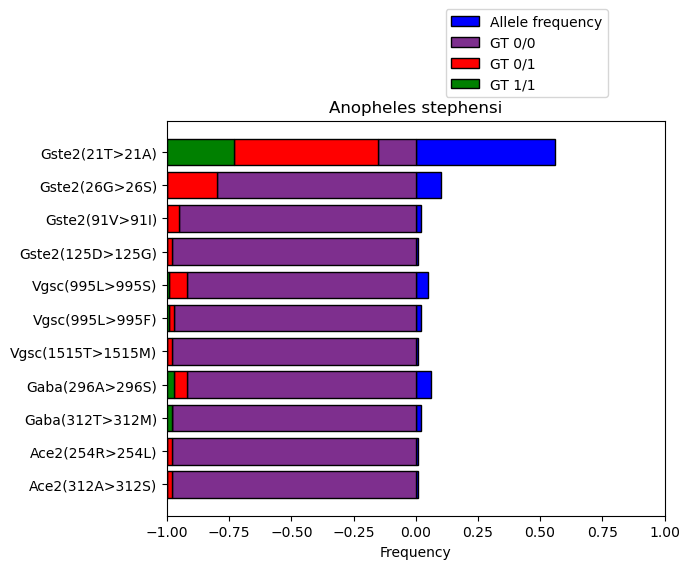

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# SNPS data
positions = np.array(merged_all_df["Label"])
aa_change = np.array(merged_all_df["alt1"])

# Genotype data
snps_gt_00 = -np.array(merged_all_df["GT:0/0"])  # GT 0/0
snps_gt_01 = -np.array(merged_all_df["GT:0/1"])  # GT 0/1
snps_gt_11 = -np.array(merged_all_df["GT:1/1"])  # GT 1/1

# Plotting
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the allele frequency
ax.barh(positions, aa_change, color='blue', edgecolor='black', label='Allele frequency')

# Plot stacked genotype frequencies
bottom = np.zeros(len(positions))
ax.barh(positions, snps_gt_00, left=bottom, color="#7E2F8E", edgecolor='black', label='GT 0/0')
bottom += snps_gt_00
ax.barh(positions, snps_gt_01, left=bottom, color='red', edgecolor='black', label='GT 0/1')
bottom += snps_gt_01
ax.barh(positions, snps_gt_11, left=bottom, color='green', edgecolor='black', label='GT 1/1')


# Adding labels and title
ax.set_xlabel('Frequency')
#ax.set_xlim(-10, 10)
ax.set_title('Anopheles stephensi')
ax.legend(loc='upper right',bbox_to_anchor=(0.9, 1.3))
ax.set_xlim(-1, 1)
# Display the plot
plt.tight_layout()
plt.show()